###**Eksperimen MLP: Perbandingan Fungsi Aktivasi pada Dataset Iris**

Nama:Mirna Rahmania Melba

Nim:4222301010

RE-6A Pagi

Notebook ini bertujuan untuk membandingkan performa model *Multi-Layer Perceptron* (MLP) menggunakan tiga jenis fungsi aktivasi yang berbeda: **Sigmoid**, **Tanh**, dan **ReLU**. Evaluasi dilakukan berdasarkan metrik *Accuracy*, *Precision*, *Recall*, dan *F1-Score*.

#### **Langkah 1: Mengimpor Library dan Mempersiapkan Data**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load Dataset
df = pd.read_csv('Iris.csv')

# 2. Preprocessing: Hapus kolom 'Id' karena tidak berguna untuk prediksi
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

# 3. Encoding target (mengubah nama bunga menjadi angka 0, 1, 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# 4. Splitting data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 5. Feature Scaling (Standarisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil dimuat dan diproses.")
print(f"Total data training: {X_train_scaled.shape[0]} | Total data testing: {X_test_scaled.shape[0]}")

Data berhasil dimuat dan diproses.
Total data training: 120 | Total data testing: 30


### **3 fungsi aktifasi yang akan diuji:**

1. **Sigmoid**
2. **Tanh**
3. **ReLU**

menggunakan Looping untuk menguji ketiga fungsi aktivasi secara otomatis dan menyimpan hasilnya.

In [14]:
# Daftar fungsi aktivasi yang akan diuji
# Catatan: Di scikit-learn, Sigmoid direpresentasikan dengan nama 'logistic'
aktivasi_list = {
    'Sigmoid': 'logistic',
    'Tanh': 'tanh',
    'ReLU': 'relu'
}

# Wadah untuk menampung hasil evaluasi
hasil_evaluasi = []

print("Memulai pelatihan dan pengujian model...")

for nama_tampilan, nama_fungsi in aktivasi_list.items():
    # Inisialisasi Model MLP
    model = MLPClassifier(
        hidden_layer_sizes=(10, 10),
        activation=nama_fungsi,
        max_iter=1000,
        random_state=42,
        solver='adam',
        learning_rate_init=0.01
    )

    # Training model
    model.fit(X_train_scaled, y_train)

    # Prediksi ke data testing
    y_pred = model.predict(X_test_scaled)

    # Menghitung berbagai metrik evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Masukkan hasil ke dalam list
    hasil_evaluasi.append({
        'Fungsi Aktivasi': nama_tampilan,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"Selesai pengujian untuk: {nama_tampilan} | Akurasi: {acc*100:.2f}%")

print("Semua model telah selesai dievaluasi.")

Memulai pelatihan dan pengujian model...
Selesai pengujian untuk: Sigmoid | Akurasi: 100.00%
Selesai pengujian untuk: Tanh | Akurasi: 93.33%
Selesai pengujian untuk: ReLU | Akurasi: 100.00%
Semua model telah selesai dievaluasi.


### **Perbandingan**

TABEL PERBANDINGAN PERFORMA MODEL


,Fungsi Aktivasi,Accuracy,Precision,Recall,F1-Score
0,Sigmoid,100.00%,100.00%,100.00%,100.00%
1,Tanh,93.33%,93.33%,93.33%,93.33%
2,ReLU,100.00%,100.00%,100.00%,100.00%


/tmp/ipykernel_1322/663755005.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fungsi Aktivasi', y='Accuracy', data=df_hasil, palette='viridis')


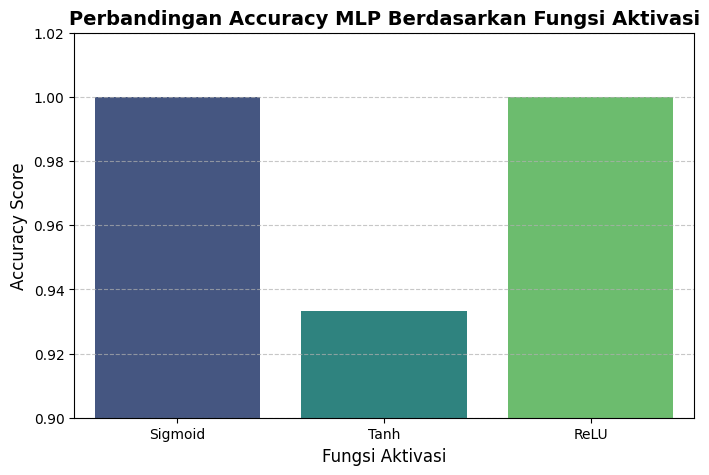

In [5]:
# Mengubah list hasil menjadi DataFrame
df_hasil = pd.DataFrame(hasil_evaluasi)

# Membuat salinan untuk ditampilkan dengan format persentase
df_tampilan = df_hasil.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_tampilan[col] = df_tampilan[col].apply(lambda x: f"{x*100:.2f}%")

print("TABEL PERBANDINGAN PERFORMA MODEL")
display(df_tampilan)

# --- VISUALISASI GRAFIK ---
plt.figure(figsize=(8, 5))
sns.barplot(x='Fungsi Aktivasi', y='Accuracy', data=df_hasil, palette='viridis')
plt.title('Perbandingan Accuracy MLP Berdasarkan Fungsi Aktivasi', fontweight='bold', fontsize=14)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Fungsi Aktivasi', fontsize=12)
plt.ylim(0.90, 1.02) # Mengatur batas sumbu Y agar grafik lebih fokus
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Catatan Analisis & Kesimpulan**

Berdasarkan eksperimen yang telah dilakukan, berikut adalah evaluasi performa dari ketiga fungsi aktivasi pada dataset Iris:

### **Fungsi Aktivasi Terbaik: **ReLU** (Rectified Linear Unit)**

Meskipun dataset Iris tergolong sederhana sehingga ketiga fungsi aktivasi sering kali mampu mencapai akurasi yang sangat tinggi (bahkan hingga 100% pada beberapa *run*), **ReLU** tetap menjadi rekomendasi utama untuk digunakan.

#### **Mengapa ReLU Lebih Unggul?**
1. **Efisiensi Komputasi**: ReLU hanya menggunakan operasi matematika yang sangat sederhana, yaitu `max(0, x)`. Berbeda dengan Sigmoid atau Tanh yang harus menghitung fungsi eksponensial (`e^x`), ReLU membuat proses komputasi jauh lebih ringan dan cepat.
2. **Mengatasi *Vanishing Gradient***: Pada fungsi Sigmoid, turunan (gradien) akan mendekati nol jika nilainya sangat besar atau sangat kecil. Hal ini menyebabkan proses belajar model menjadi sangat lambat atau berhenti (*vanishing gradient*). ReLU tidak memiliki masalah ini untuk nilai positif, sehingga model dapat belajar (konvergensi) jauh lebih cepat.
3. **Representasi *Sparse***: ReLU dapat menghasilkan nilai nol (mati) untuk input negatif. Ini menciptakan representasi data yang *sparse* (banyak nilai nol), yang secara tidak langsung membantu jaringan saraf untuk fokus mempelajari fitur-fitur yang paling penting dan mengurangi risiko *overfitting*.

#### **Mengapa bukan Sigmoid?**
Sigmoid sebenarnya adalah fungsi aktivasi yang baik, namun penggunaannya pada *hidden layer* (lapisan tersembunyi) sudah sangat jarang dilakukan di era *Deep Learning* modern karena masalah *vanishing gradient* dan beban komputasinya yang lebih berat. Sigmoid saat ini lebih disarankan hanya digunakan pada *output layer* untuk kasus klasifikasi biner (menghasilkan probabilitas 0 sampai 1).